# Week 6 — Model Tuning and Validation
Goal: optimize and validate a Machine Learning model using hyperparameter tuning and validation techniques to improve predictive performance and reliability.

**Dataset:** Pima Indians Diabetes Database (768 patients, 8 medical predictor features, binary outcome — diabetic or not).

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                      StratifiedKFold, cross_val_score, learning_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

sns.set_style('whitegrid')

## Step 2: Load and Explore the Dataset

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Shape:', df.shape)
df.dtypes

Shape: (768, 9)


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [4]:
# No NaNs on the surface...
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
# ...but several columns use 0 as a stand-in for missing data.
# A blood pressure or BMI of 0 isn't physically possible for a living patient.
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_check_cols:
    zeros = (df[col] == 0).sum()
    print(f'{col}: {zeros} zero values ({zeros/len(df)*100:.1f}%)')

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


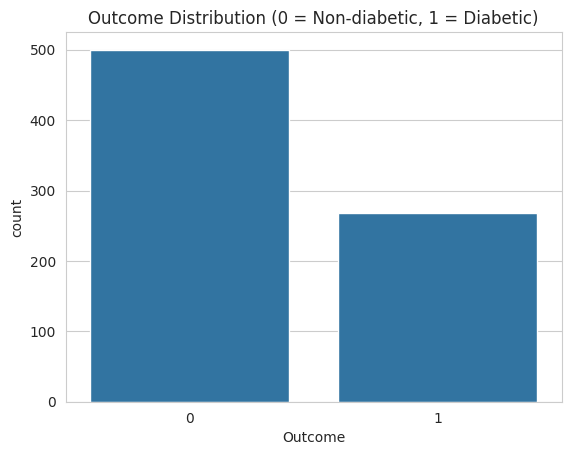

In [6]:
# Class balance
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True).round(3))
sns.countplot(data=df, x='Outcome')
plt.title('Outcome Distribution (0 = Non-diabetic, 1 = Diabetic)')
plt.show()

## Step 3: Handle Missing Data (encoded as zeros)

In [7]:
df_clean = df.copy()
for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
# Median imputation
for col in zero_check_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 4: Select Features and Target, Then Split

In [10]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (614, 8)
Testing set size: (154, 8)


In [11]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }, y_pred

## Step 5: Baseline Model

In [12]:
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_result, baseline_pred = evaluate_model('Baseline Random Forest', baseline_model, X_test, y_test)
baseline_result

{'Model': 'Baseline Random Forest',
 'Accuracy': 0.7792207792207793,
 'Precision': 0.7272727272727273,
 'Recall': 0.5925925925925926,
 'F1-Score': 0.6530612244897959,
 'ROC-AUC': 0.8191666666666666}

In [13]:
print(classification_report(y_test, baseline_pred, target_names=['Non-diabetic', 'Diabetic']))

              precision    recall  f1-score   support

Non-diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



## Step 6: Cross-Validation

In [14]:
# K-Fold cross-validation (stratified, to preserve class balance in every fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=skf, scoring='accuracy')

print('Cross-validation scores:', cv_scores.round(4))
print(f'Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross-validation scores: [0.7724 0.7317 0.7967 0.7642 0.7541]
Mean CV accuracy: 0.7638 (+/- 0.0214)


In [15]:
# Compare against the single train/test split result
print(f'Single train/test split accuracy: {baseline_result["Accuracy"]:.4f}')
print(f'5-fold CV mean accuracy:          {cv_scores.mean():.4f}')
print('A close match means the single split result is trustworthy, not a lucky draw.')

Single train/test split accuracy: 0.7792
5-fold CV mean accuracy:          0.7638
A close match means the single split result is trustworthy, not a lucky draw.


## Step 7: Hyperparameter Tuning — Grid Search

In [16]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

start = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print('Grid Search — best parameters:', grid_search.best_params_)
print('Grid Search — best CV ROC-AUC:', round(grid_search.best_score_, 4))
print(f'Grid Search — combinations tested: {len(grid_search.cv_results_["params"])}, time: {grid_time:.1f}s')

Grid Search — best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Grid Search — best CV ROC-AUC: 0.8391
Grid Search — combinations tested: 108, time: 113.0s


## Step 8: Hyperparameter Tuning — Random Search

In [17]:
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6],
    'max_features': ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

start = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start

print('Random Search — best parameters:', random_search.best_params_)
print('Random Search — best CV ROC-AUC:', round(random_search.best_score_, 4))
print(f'Random Search — combinations tested: 40 (out of {6*7*6*6*3} possible), time: {random_time:.1f}s')

Random Search — best parameters: {'n_estimators': 250, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3}
Random Search — best CV ROC-AUC: 0.8417
Random Search — combinations tested: 40 (out of 4536 possible), time: 74.4s


## Step 9: Grid Search vs. Random Search — Parameter Selection

In [18]:
search_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Combinations Tested': [len(grid_search.cv_results_['params']), 40],
    'Best CV ROC-AUC': [grid_search.best_score_, random_search.best_score_],
    'Time (s)': [round(grid_time, 1), round(random_time, 1)],
})
search_comparison

,Method,Combinations Tested,Best CV ROC-AUC,Time (s)
0,Grid Search,108,0.839129,113.0
1,Random Search,40,0.841699,74.4


In [19]:
# Evaluate BOTH tuned candidates on the held-out test set — don't just trust the CV score
grid_model = grid_search.best_estimator_
grid_model.fit(X_train, y_train)
grid_result, grid_pred = evaluate_model('Tuned (Grid Search)', grid_model, X_test, y_test)

random_model = random_search.best_estimator_
random_model.fit(X_train, y_train)
random_result, random_pred = evaluate_model('Tuned (Random Search)', random_model, X_test, y_test)

pd.DataFrame([baseline_result, grid_result, random_result]).set_index('Model')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
Tuned (Grid Search),0.733766,0.651163,0.518519,0.577320,0.812778
Tuned (Random Search),0.714286,0.631579,0.444444,0.521739,0.802593


In [20]:
tuned_model = grid_model
best_search_name = 'Grid Search'
tuned_result, tuned_pred = grid_result, grid_pred
print('Carried forward: Grid Search tuned model')
print('Parameters:', grid_search.best_params_)

Carried forward: Grid Search tuned model
Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


## Step 10: Classification Report — Tuned Model

In [21]:
print(classification_report(y_test, tuned_pred, target_names=['Non-diabetic', 'Diabetic']))

              precision    recall  f1-score   support

Non-diabetic       0.77      0.85      0.81       100
    Diabetic       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



## Step 11: Bias-Variance Tradeoff
A learning curve shows training vs. cross-validation score as training set size grows — the classic way to visually diagnose overfitting (high variance) vs. underfitting (high bias).

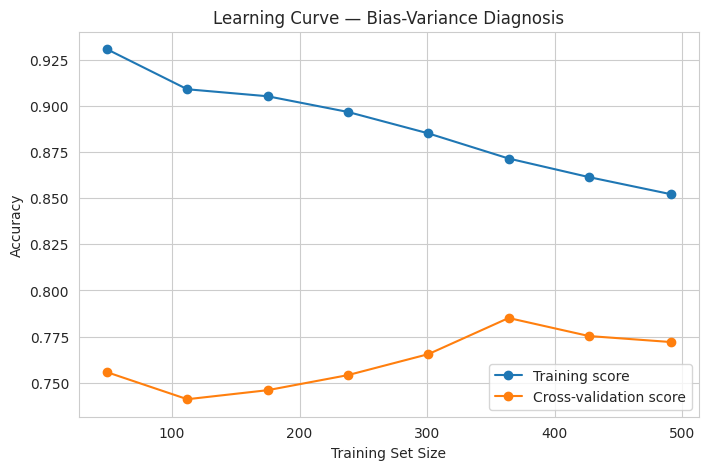

Final training score: 0.8521
Final validation score: 0.7721
Gap: 0.0801


In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    tuned_model, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Bias-Variance Diagnosis')
plt.legend(loc='lower right')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final training score: {train_mean[-1]:.4f}')
print(f'Final validation score: {val_mean[-1]:.4f}')
print(f'Gap: {gap:.4f}')

## Step 12: Final Model Comparison

In [23]:
comparison = pd.DataFrame([baseline_result, grid_result, random_result]).set_index('Model')
comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167
Tuned (Grid Search),0.733766,0.651163,0.518519,0.577320,0.812778
Tuned (Random Search),0.714286,0.631579,0.444444,0.521739,0.802593


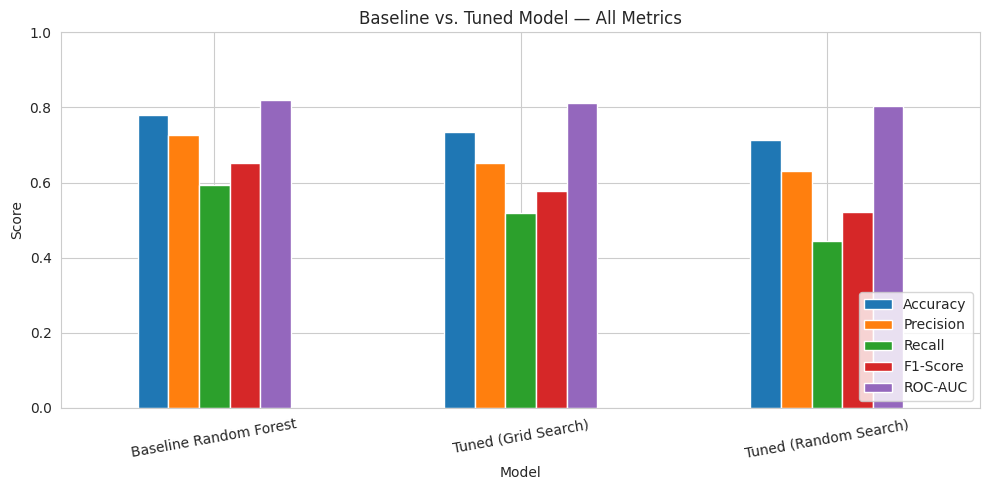

In [24]:
comparison.plot(kind='bar', figsize=(10,5))
plt.title('Baseline vs. Tuned Model — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=10)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

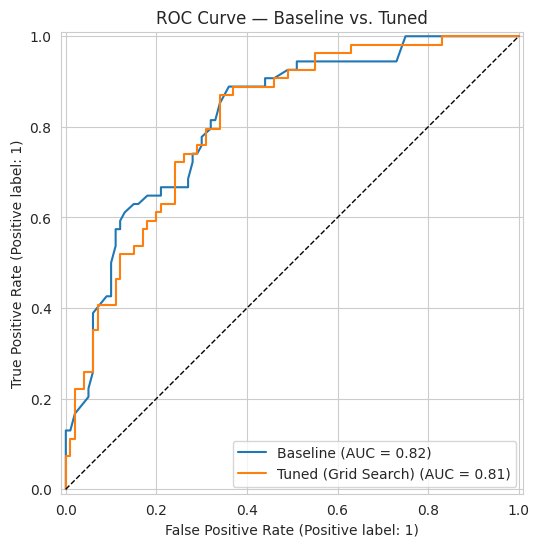

In [25]:
# ROC curves
fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test, name='Baseline', ax=ax)
RocCurveDisplay.from_estimator(tuned_model, X_test, y_test, name=f'Tuned ({best_search_name})', ax=ax)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_title('ROC Curve — Baseline vs. Tuned')
plt.show()

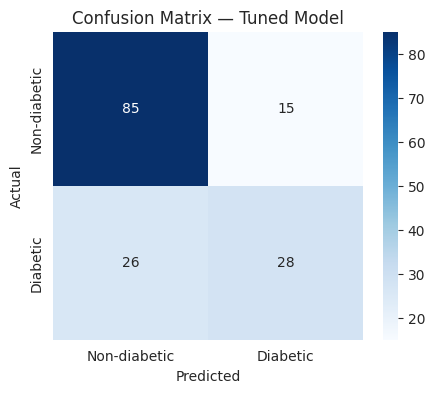

In [26]:
cm = confusion_matrix(y_test, tuned_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-diabetic', 'Diabetic'], yticklabels=['Non-diabetic', 'Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Tuned Model')
plt.show()